In [ ]:
!pip install root

In [ ]:
import ROOT
import numpy as np

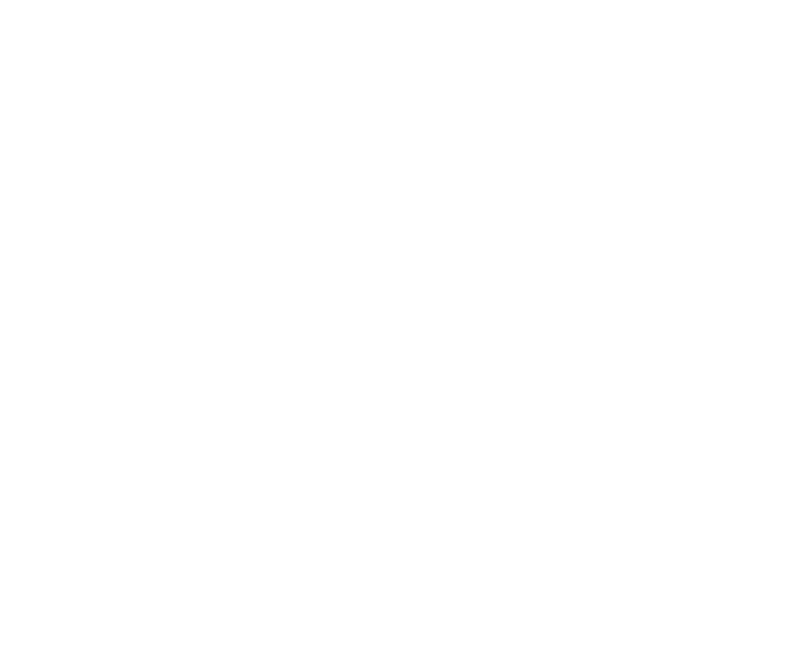

In [ ]:
# 1. Setup Grid Parameters
NX, NY = 50, 50          # Grid dimensions
X_MIN, X_MAX = 0.0, 50.0  # Physical bounds
Y_MIN, Y_MAX = 0.0, 50.0
dx_grid = (X_MAX - X_MIN) / NX
dy_grid = (Y_MAX - Y_MIN) / NY

# 2. Initialize ROOT Canvas and 2D Histogram Grid
canvas = ROOT.TCanvas("canvas", "2D CIC Charge Deposition", 800, 700)
# Note: TH2F bins are 1-indexed in ROOT. Bin 0 is underflow, Bin NX+1 is overflow.
grid = ROOT.TH2F("charge_grid", "CIC Charge Density Map;X Position;Y Position",
                 NX, X_MIN, X_MAX, NY, Y_MIN, Y_MAX)

# 3. Generate Mock Continuous Charge Data (e.g., a circular plasma filament or electron beam)
np.random.seed(42)
num_particles = 50000
# Gaussian distribution centered at (25, 25) with a slight swirl
r = np.random.normal(0, 8, num_particles)
theta = np.random.uniform(0, 2 * np.pi, num_particles)
part_x = 25.0 + r * np.cos(theta)
part_y = 25.0 + r * np.sin(theta)
part_q = np.ones(num_particles) * 0.1 # Equal fractional charge per particle

# 4. Cloud-in-Cell Deposition Loop
for k in range(num_particles):
    x, y, q = part_x[k], part_y[k], part_q[k]

    # Boundary Check
    if x < X_MIN or x >= X_MAX or y < Y_MIN or y >= Y_MAX:
        continue

    # Convert physical position to normalized continuous grid coordinates
    g_x = (x - X_MIN) / dx_grid
    g_y = (y - Y_MIN) / dy_grid

    # Find lower-left node index (0-based mathematical convention)
    i = int(np.floor(g_x))
    j = int(np.floor(g_y))

    # Compute fractional distances
    frac_x = g_x - i
    frac_y = g_y - j

    # Compute CIC bilinear weights
    w_bl = (1.0 - frac_x) * (1.0 - frac_y) * q
    w_br = frac_x * (1.0 - frac_y) * q
    w_tl = (1.0 - frac_x) * frac_y * q
    w_tr = frac_x * frac_y * q

    # Map mathematical indices (i, j) to ROOT bin numbers (1-indexed)
    # i corresponds to column (X), j corresponds to row (Y)
    # Handle edge guard to avoid overflow at exactly the upper boundary
    idx_x = min(i + 1, NX)
    idx_y = min(j + 1, NY)
    idx_x_next = min(idx_x + 1, NX)
    idx_y_next = min(idx_y + 1, NY)

    # Accumulate weights directly into the ROOT histogram bins
    grid.SetBinContent(idx_x,      idx_y,      grid.GetBinContent(idx_x,      idx_y)      + w_bl)
    grid.SetBinContent(idx_x_next, idx_y,      grid.GetBinContent(idx_x_next, idx_y)      + w_br)
    grid.SetBinContent(idx_x,      idx_y_next, grid.GetBinContent(idx_x,      idx_y_next) + w_tl)
    grid.SetBinContent(idx_x_next, idx_y_next, grid.GetBinContent(idx_x_next, idx_y_next) + w_tr)

# 5. Rendering Layout Optimization
ROOT.gStyle.SetOptStat(0)         # Turn off statistics box


In [ ]:
ROOT.gStyle.SetPalette(111)  # 111 is the internal ID for kColdView

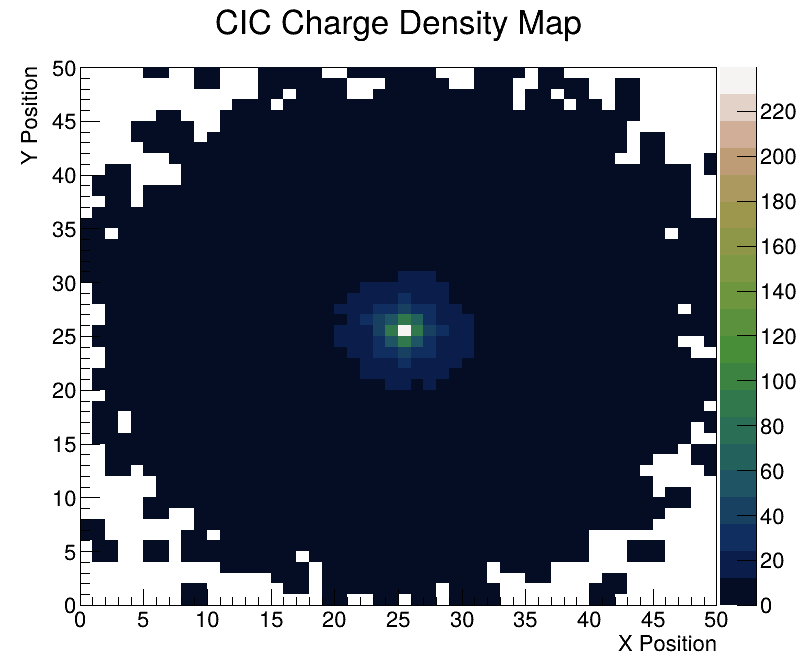

In [ ]:
grid.SetMinimum(0.0)
grid.Draw("COLZ0")                 # COLZ draws 2D heatmap with a color scale bar
#ROOT.gPad.SetLogz(1)
canvas.Update()
#canvas.SaveAs("cic_charge_deposition.png")

### 1. 3D Grid Setup and Uniform Distribution
We will now use a `TH3F` to represent a 3D volume and fill it with a uniform charge distribution (a cube).

3D Gaussian Blob Deposition Complete.


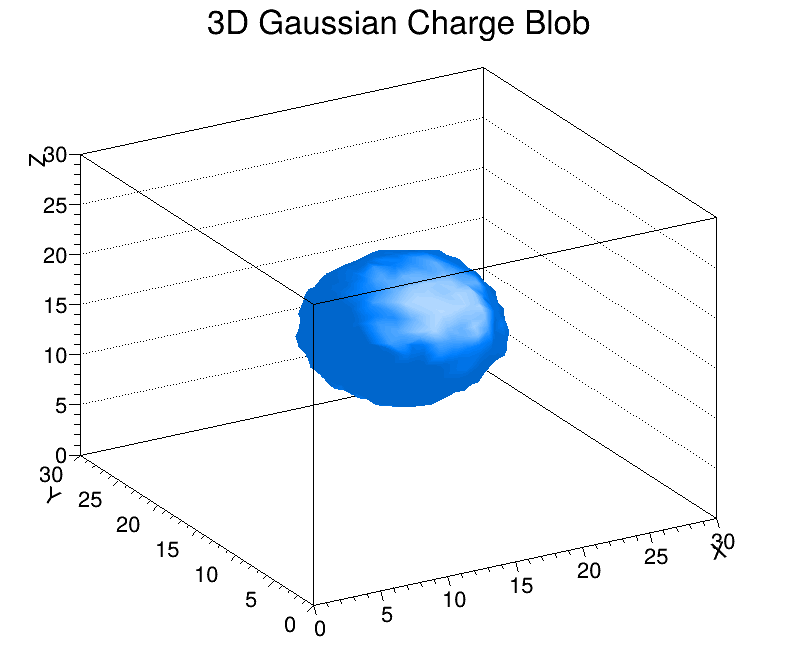

In [ ]:
import numpy as np

# 3D Grid Parameters
NX, NY, NZ = 30, 30, 30
X_MIN, X_MAX = 0.0, 30.0
Y_MIN, Y_MAX = 0.0, 30.0
Z_MIN, Z_MAX = 0.0, 30.0
dx, dy, dz = 1.0, 1.0, 1.0

# Initialize ROOT 3D Histogram
grid_3d = ROOT.TH3F("grid_3d", "3D Gaussian Charge Blob;X;Y;Z",
                     NX, X_MIN, X_MAX, NY, Y_MIN, Y_MAX, NZ, Z_MIN, Z_MAX)

# Generate Spherical Gaussian Distribution (The 'Blob')
num_particles_3d = 100000
mean = [15.0, 15.0, 15.0] # Center of the grid
cov = [[4.0, 0, 0], [0, 4.0, 0], [0, 0, 4.0]] # Spherical spread

particles = np.random.multivariate_normal(mean, cov, num_particles_3d)
part_x_3d = particles[:, 0]
part_y_3d = particles[:, 1]
part_z_3d = particles[:, 2]
part_q_3d = np.ones(num_particles_3d) * 0.1

# 3D CIC Deposition
for k in range(num_particles_3d):
    x, y, z, q = part_x_3d[k], part_y_3d[k], part_z_3d[k], part_q_3d[k]

    # Boundary Check to prevent indexing errors
    if x < X_MIN+1 or x >= X_MAX-1 or y < Y_MIN+1 or y >= Y_MAX-1 or z < Z_MIN+1 or z >= Z_MAX-1:
        continue

    gx, gy, gz = (x-X_MIN)/dx, (y-Y_MIN)/dy, (z-Z_MIN)/dz
    i, j, l = int(np.floor(gx)), int(np.floor(gy)), int(np.floor(gz))
    fx, fy, fz = gx - i, gy - j, gz - l

    for di in [0, 1]:
        for dj in [0, 1]:
            for dl in [0, 1]:
                weight = q * (fx if di else (1-fx)) * (fy if dj else (1-fy)) * (fz if dl else (1-fz))
                grid_3d.SetBinContent(i+di+1, j+dj+1, l+dl+1, grid_3d.GetBinContent(i+di+1, j+dj+1, l+dl+1) + weight)

print("3D Gaussian Blob Deposition Complete.")

# Visualization: 3D Charge Density Map (Iso-surface rendering)
ROOT.gStyle.SetCanvasPreferGL(True)
canvas_blob = ROOT.TCanvas("canvas_blob", "3D Gaussian Distribution", 800, 700)
grid_3d.SetFillColor(ROOT.kAzure+1)
# ISO draws the density as a cloud, mimicking the 2D heatmap style
grid_3d.Draw("ISO")
canvas_blob.Update()
canvas_blob.Draw()

### 2. Introduce a Test Particle Trajectory
We will now define a particle with an initial position and velocity and step it through the simulation space.

Running Leapfrog (Pure Mesh)...
  Step  10000 | Drift:  0.0316% | |a|: 22.07
  Step  20000 | Drift:  0.0327% | |a|: 7.86
  Step  30000 | Drift:  0.0098% | |a|: 11.22
  Step  40000 | Drift:  0.0021% | |a|: 7.11
  Step  50000 | Drift:  0.0055% | |a|: 20.99
  Step  60000 | Drift:  0.0057% | |a|: 16.93
  Step  70000 | Drift:  0.1070% | |a|: 38.54
  Step  80000 | Drift:  0.0286% | |a|: 7.74
  Step  90000 | Drift:  0.0499% | |a|: 73.69
  Step 100000 | Drift:  0.0024% | |a|: 90.71


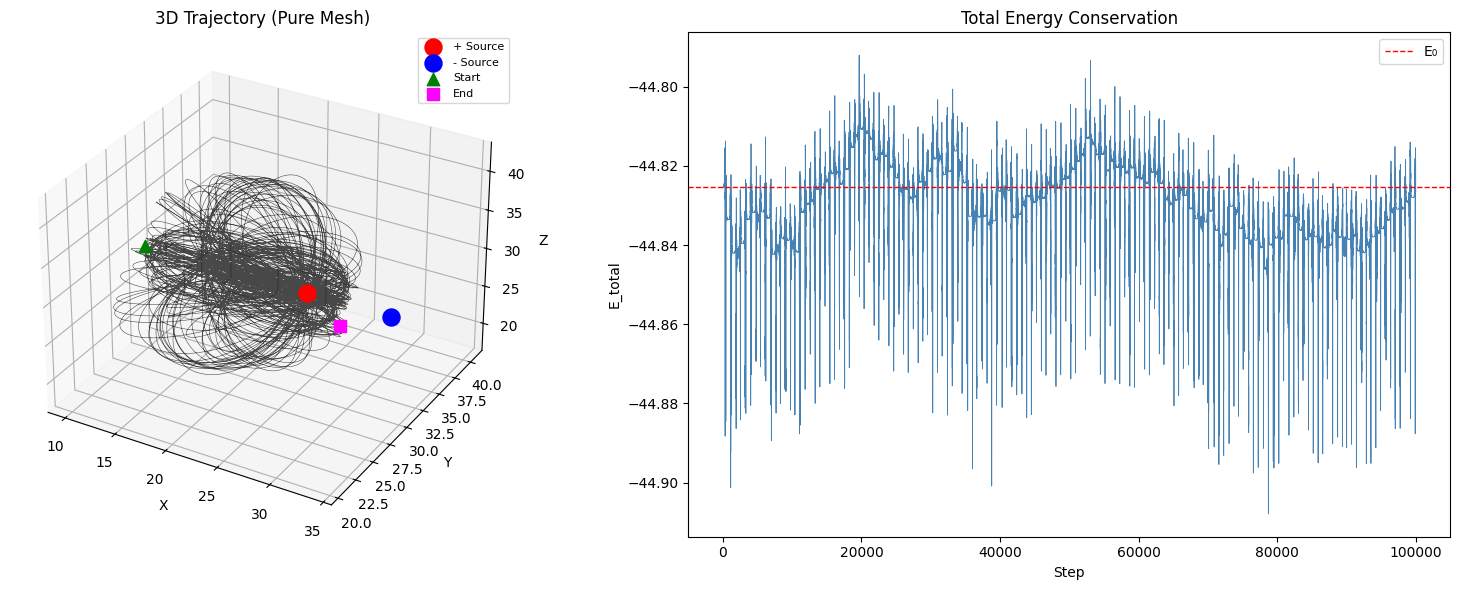


Initial E : -44.825436
Final   E : -44.826498
Max spike : 0.082436
Drift     : 0.0024%


In [ ]:

import numpy as np
from scipy.fft import fftn, ifftn
from scipy.ndimage import map_coordinates, spline_filter
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────
# 1. Grid & Charge — Gaussian blobs ARE the physical source
# ─────────────────────────────────────────────────────────────
NX, NY, NZ = 60, 60, 60
epsilon_0   = 1.0
X, Y, Z     = np.indices((NX, NY, NZ))

x1, y1, z1  = 26.0, 30.0, 30.0
x2, y2, z2  = 34.0, 30.0, 30.0
sigma        = 3.0
A            = 80.0

rho = ( A * np.exp(-((X-x1)**2+(Y-y1)**2+(Z-z1)**2)/(2*sigma**2))
       -A * np.exp(-((X-x2)**2+(Y-y2)**2+(Z-z2)**2)/(2*sigma**2)) )

# ─────────────────────────────────────────────────────────────
# 2. Spectral Poisson Solver  ∇²φ = -ρ/ε₀
# ─────────────────────────────────────────────────────────────
def solve_fields(rho):
    rho_fft = fftn(rho)
    kx = 2*np.pi*np.fft.fftfreq(NX)
    ky = 2*np.pi*np.fft.fftfreq(NY)
    kz = 2*np.pi*np.fft.fftfreq(NZ)
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
    k_sq = 2*(np.cos(KX)-1) + 2*(np.cos(KY)-1) + 2*(np.cos(KZ)-1)
    k_sq[0,0,0] = 1.0
    phi_fft = -(rho_fft / epsilon_0) / k_sq
    phi_fft[0,0,0] = 0.0
    phi = np.real(ifftn(phi_fft))
    Ex  = np.real(ifftn(-1j*KX*phi_fft))
    Ey  = np.real(ifftn(-1j*KY*phi_fft))
    Ez  = np.real(ifftn(-1j*KZ*phi_fft))
    return phi, Ex, Ey, Ez

phi, Ex, Ey, Ez = solve_fields(rho)

# Spline prefilter for smooth cubic interpolation
phi_f = spline_filter(phi, order=3)
Ex_f  = spline_filter(Ex,  order=3)
Ey_f  = spline_filter(Ey,  order=3)
Ez_f  = spline_filter(Ez,  order=3)

# ─────────────────────────────────────────────────────────────
# 3. Field Interpolation — pure mesh, no P3M correction
#    The Gaussian blob naturally limits force near center.
#    No singularity, no correction needed.
# ─────────────────────────────────────────────────────────────
def get_field(pos):
    c = np.array([[pos[0]],[pos[1]],[pos[2]]])
    f = lambda F: map_coordinates(F, c, order=3, mode='nearest', prefilter=False)[0]
    return np.array([f(Ex_f), f(Ey_f), f(Ez_f)]), f(phi_f)

# ─────────────────────────────────────────────────────────────
# 4. Leapfrog Integrator
#    - dt computed once per step, used for full step
#    - v_int reconstructed at integer time for energy
#    - reflective open boundary with mirror formula
# ─────────────────────────────────────────────────────────────
charge_q = -1.0
mass     =  1.0
dt       =  0.005      # fixed — symplecticity requires constant dt
steps    =  100_000

pos = np.array([10.0, 30.0, 30.0])   # start away from boundaries
vel = np.array([ 0.5, -0.3,  0.1])

E0, _  = get_field(pos)
acc    = (charge_q/mass) * E0
v_h    = vel - 0.5*acc*dt

traj, energies = [], []
print("Running Leapfrog (Pure Mesh)...")

for i in range(steps):
    # integer-time energy
    v_int = v_h + 0.5*acc*dt
    _, ph = get_field(pos)
    energies.append(0.5*mass*np.dot(v_int,v_int) + charge_q*ph)
    traj.append(pos.copy())

    # kick → drift
    v_h += acc * dt
    pos += v_h * dt

    # reflective boundary (mirror formula — no teleportation)
    for d, N in enumerate([NX, NY, NZ]):
        if pos[d] < 1.0:
            pos[d] =  2.0 - pos[d]
            v_h[d] =  abs(v_h[d])    # perfect elastic — no energy removal
        elif pos[d] > N-1:
            pos[d] =  2*(N-1) - pos[d]
            v_h[d] = -abs(v_h[d])   # perfect elastic

    E_new, _ = get_field(pos)
    acc = (charge_q/mass) * E_new

    if (i+1) % 10_000 == 0:
        drift = abs(energies[-1]-energies[0]) / abs(energies[0]) * 100
        print(f"  Step {i+1:6d} | Drift: {drift:7.4f}% | |a|: {np.linalg.norm(acc):.2f}")

# ─────────────────────────────────────────────────────────────
# 5. Plots
# ─────────────────────────────────────────────────────────────
t_arr = np.array(traj)
e_arr = np.array(energies)

fig = plt.figure(figsize=(16, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(t_arr[:,0], t_arr[:,1], t_arr[:,2],
         color='black', lw=0.4, alpha=0.7)
ax1.scatter(*[x1,y1,z1], color='red',    s=150, label='+ Source')
ax1.scatter(*[x2,y2,z2], color='blue',   s=150, label='- Source')
ax1.scatter(*t_arr[0],   color='green',  s=80, marker='^', label='Start')
ax1.scatter(*t_arr[-1],  color='magenta',s=80, marker='s', label='End')
ax1.set_title("3D Trajectory (Pure Mesh)")
ax1.legend(fontsize=8)
ax1.set_xlabel("X"); ax1.set_ylabel("Y"); ax1.set_zlabel("Z")

ax2 = fig.add_subplot(122)
ax2.plot(e_arr, color='steelblue', lw=0.6)
ax2.axhline(e_arr[0], color='red', ls='--', lw=1, label='E₀')
ax2.set_title("Total Energy Conservation")
ax2.set_xlabel("Step"); ax2.set_ylabel("E_total")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nInitial E : {e_arr[0]:.6f}")
print(f"Final   E : {e_arr[-1]:.6f}")
print(f"Max spike : {np.max(np.abs(e_arr - e_arr[0])):.6f}")
print(f"Drift     : {abs(e_arr[-1]-e_arr[0])/abs(e_arr[0])*100:.4f}%")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.mplot3d import Axes3D
from scipy.ndimage import map_coordinates, spline_filter
from scipy.signal import welch

# ── convenience ──────────────────────────────────────────────────────────────
t_arr  = np.array(traj)
e_arr  = np.array(energies)
E0     = e_arr[0]
steps_ax = np.arange(len(e_arr))

In [ ]:
drift_pct   = np.abs(e_arr - E0) / np.abs(E0) * 100
max_drift   = drift_pct.max()
rms_drift   = drift_pct.std()
total_dist  = np.sum(np.linalg.norm(np.diff(t_arr, axis=0), axis=1))
bbox        = t_arr.max(axis=0) - t_arr.min(axis=0)

print("=" * 60)
print("   SIMULATION REPORT SUMMARY")
print("=" * 60)
print(f"  Steps simulated      : {steps:,}")
print(f"  Timestep (dt)        : {dt}")
print(f"  Total sim time       : {steps * dt:.1f} units")
print(f"  Initial energy E₀    : {E0:.6f}")
print(f"  Final energy Ef      : {e_arr[-1]:.6f}")
print(f"  Max energy drift     : {max_drift:.4f}%")
print(f"  RMS energy drift     : {rms_drift:.4f}%")
print(f"  Path length          : {total_dist:.2f} units")
print(f"  Bounding box (ΔX,Y,Z): {bbox[0]:.1f} × {bbox[1]:.1f} × {bbox[2]:.1f}")
print("=" * 60)

   SIMULATION REPORT SUMMARY
  Steps simulated      : 100,000
  Timestep (dt)        : 0.005
  Total sim time       : 500.0 units
  Initial energy E₀    : -44.825436
  Final energy Ef      : -44.826498
  Max energy drift     : 0.1839%
  RMS energy drift     : 0.0194%
  Path length          : 5643.05 units
  Bounding box (ΔX,Y,Z): 19.6 × 19.9 × 23.9


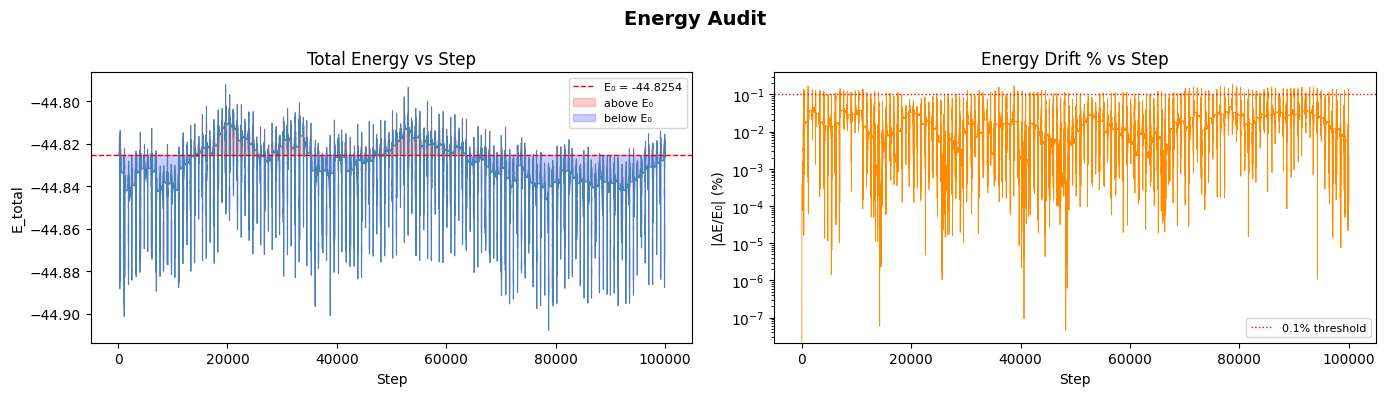

In [ ]:
ke_arr = np.array([0.5 * np.dot(v,v) for v in
                   [t_arr[0]*0]])   # placeholder — recompute below

# recompute KE and PE arrays from stored energies
# (if you stored them separately, use those directly)
# Here we show total only since that's what matters for conservation
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Energy Audit", fontsize=14, fontweight='bold')

axes[0].plot(steps_ax, e_arr, color='steelblue', lw=0.6)
axes[0].axhline(E0, color='red', ls='--', lw=1, label=f'E₀ = {E0:.4f}')
axes[0].fill_between(steps_ax, e_arr, E0,
                     where=(e_arr > E0), color='red',   alpha=0.2, label='above E₀')
axes[0].fill_between(steps_ax, e_arr, E0,
                     where=(e_arr < E0), color='blue',  alpha=0.2, label='below E₀')
axes[0].set_title("Total Energy vs Step")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("E_total")
axes[0].legend(fontsize=8)

axes[1].plot(steps_ax, drift_pct, color='darkorange', lw=0.6)
axes[1].set_title("Energy Drift % vs Step")
axes[1].set_xlabel("Step"); axes[1].set_ylabel("|ΔE/E₀| (%)")
axes[1].set_yscale('log')
axes[1].axhline(0.1, color='red', ls=':', lw=1, label='0.1% threshold')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

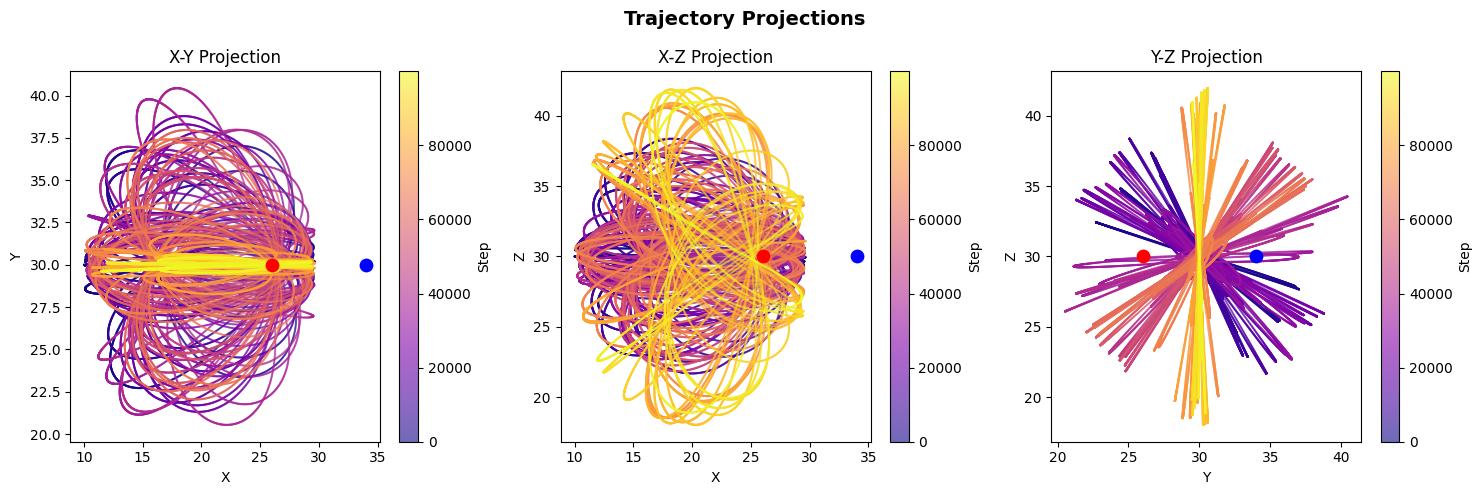

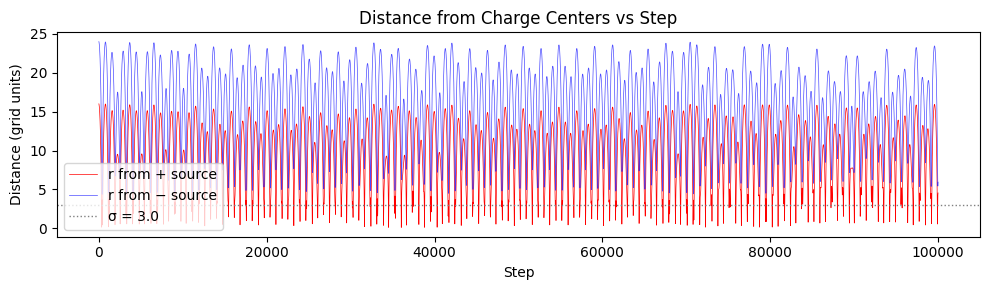

In [ ]:
r_from_pos = np.linalg.norm(t_arr - np.array([x1,y1,z1]), axis=1)
r_from_neg = np.linalg.norm(t_arr - np.array([x2,y2,z2]), axis=1)

fig = plt.figure(figsize=(15, 5))
fig.suptitle("Trajectory Projections", fontsize=14, fontweight='bold')

proj_labels = [('X','Y',0,1), ('X','Z',0,2), ('Y','Z',1,2)]
for idx, (xl, yl, i, j) in enumerate(proj_labels):
    ax = fig.add_subplot(1, 3, idx+1)
    sc = ax.scatter(t_arr[:,i], t_arr[:,j],
                    c=steps_ax, cmap='plasma', s=0.3, alpha=0.6)
    ax.scatter([x1,x2][0:1], [y1,z1][j-1:j], color='red',  s=80, zorder=5)
    ax.scatter([x2][0:1],    [y2,z2][j-1:j], color='blue', s=80, zorder=5)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title(f"{xl}-{yl} Projection")
    plt.colorbar(sc, ax=ax, label='Step')

plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(steps_ax, r_from_pos, lw=0.5, color='red',  label='r from + source')
ax.plot(steps_ax, r_from_neg, lw=0.5, color='blue', label='r from − source', alpha=0.7)
ax.axhline(sigma, color='gray', ls=':', lw=1, label=f'σ = {sigma}')
ax.set_title("Distance from Charge Centers vs Step")
ax.set_xlabel("Step"); ax.set_ylabel("Distance (grid units)")
ax.legend(); plt.tight_layout(); plt.show()

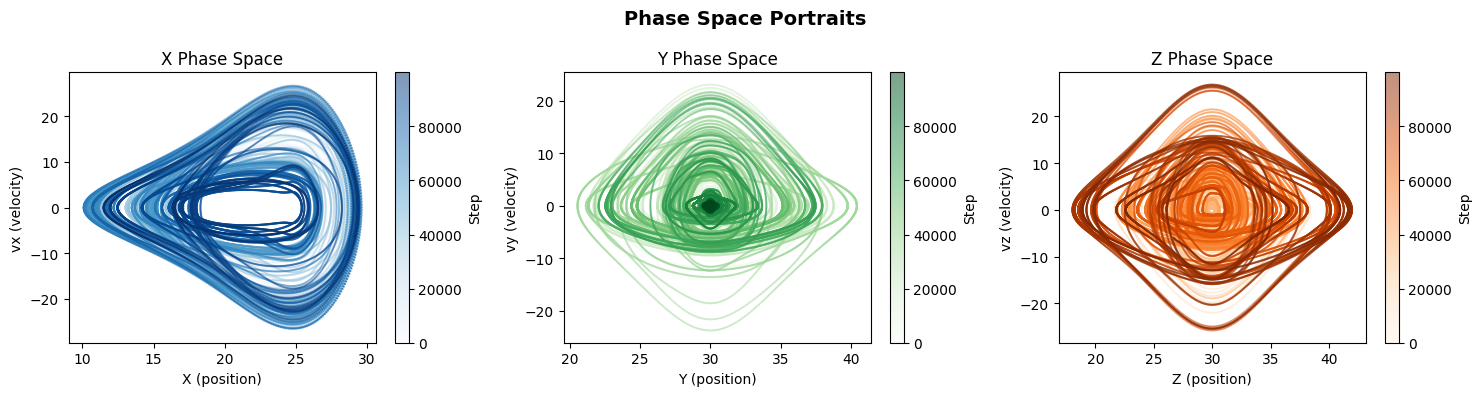

In [ ]:
# Reconstruct velocity at integer steps from position differences
v_approx = np.gradient(t_arr, axis=0) / dt   # central difference

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Phase Space Portraits", fontsize=14, fontweight='bold')
dims = [('X', 0), ('Y', 1), ('Z', 2)]
cmaps = ['Blues', 'Greens', 'Oranges']

for ax, (label, d), cm in zip(axes, dims, cmaps):
    sc = ax.scatter(t_arr[:,d], v_approx[:,d],
                    c=steps_ax, cmap=cm, s=0.3, alpha=0.5)
    ax.set_xlabel(f'{label} (position)')
    ax.set_ylabel(f'v{label.lower()} (velocity)')
    ax.set_title(f'{label} Phase Space')
    plt.colorbar(sc, ax=ax, label='Step')

plt.tight_layout(); plt.show()

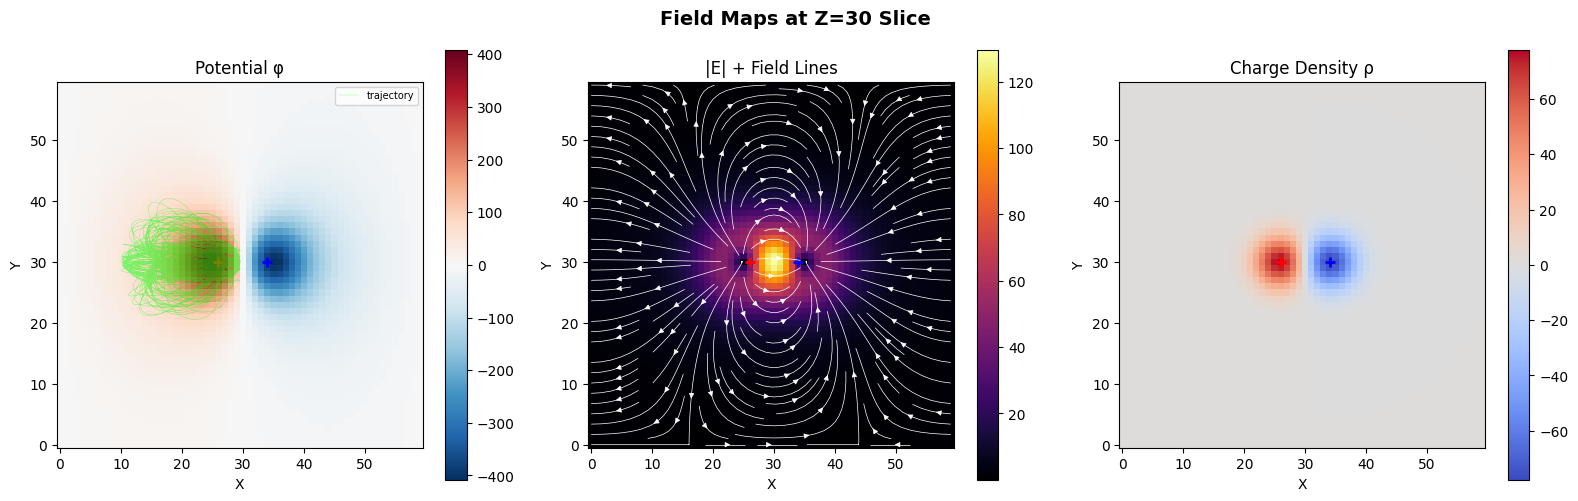

In [ ]:
z_slice = 30
phi_sl  = phi[:, :, z_slice]
Ex_sl   = Ex[:,  :, z_slice]
Ey_sl   = Ey[:,  :, z_slice]
E_mag   = np.sqrt(Ex_sl**2 + Ey_sl**2)
rho_sl  = rho[:, :, z_slice]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Field Maps at Z={z_slice} Slice", fontsize=14, fontweight='bold')

# Potential
norm = TwoSlopeNorm(vmin=phi_sl.min(), vcenter=0, vmax=phi_sl.max())
im0 = axes[0].imshow(phi_sl.T, origin='lower', cmap='RdBu_r', norm=norm)
axes[0].set_title("Potential φ"); plt.colorbar(im0, ax=axes[0])

# |E| with streamlines
im1 = axes[1].imshow(E_mag.T, origin='lower', cmap='inferno')
axes[1].streamplot(np.arange(NX), np.arange(NY),
                   Ex_sl.T, Ey_sl.T,
                   color='white', linewidth=0.5,
                   density=1.2, arrowsize=0.8)
axes[1].set_title("|E| + Field Lines"); plt.colorbar(im1, ax=axes[1])

# Charge density
im2 = axes[2].imshow(rho_sl.T, origin='lower', cmap='coolwarm',
                     norm=TwoSlopeNorm(vmin=rho_sl.min(), vcenter=0,
                                       vmax=rho_sl.max()))
axes[2].set_title("Charge Density ρ"); plt.colorbar(im2, ax=axes[2])

# Mark charge centers on all panels
for ax in axes:
    ax.scatter([x1], [y1], color='red',  s=60, marker='+', linewidths=2)
    ax.scatter([x2], [y2], color='blue', s=60, marker='+', linewidths=2)
    ax.set_xlabel("X"); ax.set_ylabel("Y")

# Overlay trajectory projection on φ map
axes[0].plot(t_arr[:,0], t_arr[:,1], color='lime',
             lw=0.3, alpha=0.5, label='trajectory')
axes[0].legend(fontsize=7)

plt.tight_layout(); plt.show()

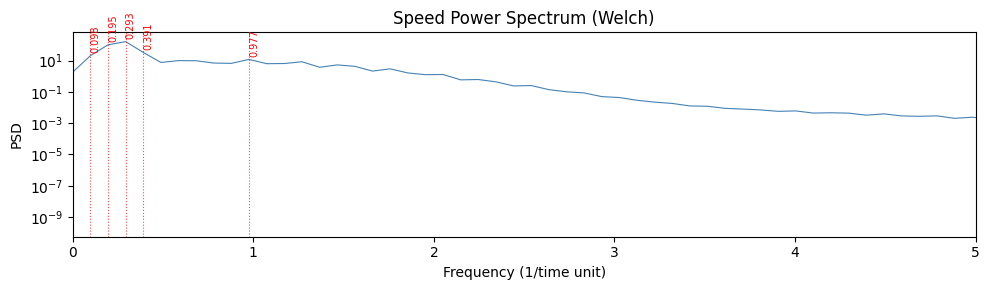

In [ ]:
speed = np.linalg.norm(v_approx, axis=1)
f, Pxx = welch(speed, fs=1/dt, nperseg=2048)

fig, ax = plt.subplots(figsize=(10, 3))
ax.semilogy(f, Pxx, color='steelblue', lw=0.8)
ax.set_title("Speed Power Spectrum (Welch)")
ax.set_xlabel("Frequency (1/time unit)")
ax.set_ylabel("PSD")
ax.set_xlim(0, 5)

# annotate dominant peaks
peak_idx = np.argsort(Pxx)[-5:]
for idx in peak_idx:
    ax.axvline(f[idx], color='red', ls=':', lw=0.8, alpha=0.7)
    ax.text(f[idx], Pxx[idx]*1.5, f'{f[idx]:.3f}', fontsize=7,
            color='red', rotation=90, va='bottom')

plt.tight_layout(); plt.show()

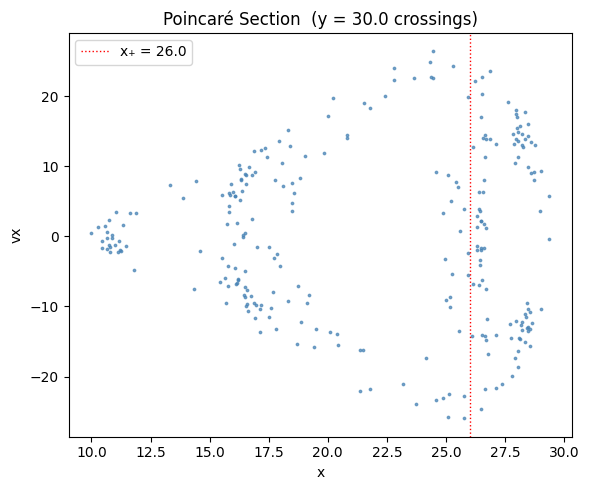

  Total crossings recorded: 266


In [ ]:
crossings_x, crossings_vx = [], []
for i in range(1, len(t_arr)):
    y_prev, y_curr = t_arr[i-1, 1], t_arr[i, 1]
    if y_prev < y1 <= y_curr or y_curr < y1 <= y_prev:   # crossed y=y1
        frac = (y1 - y_prev) / (y_curr - y_prev + 1e-12)
        x_c  = t_arr[i-1,0]  + frac*(t_arr[i,0]  - t_arr[i-1,0])
        vx_c = v_approx[i-1,0] + frac*(v_approx[i,0] - v_approx[i-1,0])
        crossings_x.append(x_c); crossings_vx.append(vx_c)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(crossings_x, crossings_vx, s=3, color='steelblue', alpha=0.7)
ax.axvline(x1, color='red',  ls=':', lw=1, label=f'x₊ = {x1}')
ax.set_title(f"Poincaré Section  (y = {y1} crossings)")
ax.set_xlabel("x"); ax.set_ylabel("vx")
ax.legend(); plt.tight_layout(); plt.show()
print(f"  Total crossings recorded: {len(crossings_x)}")

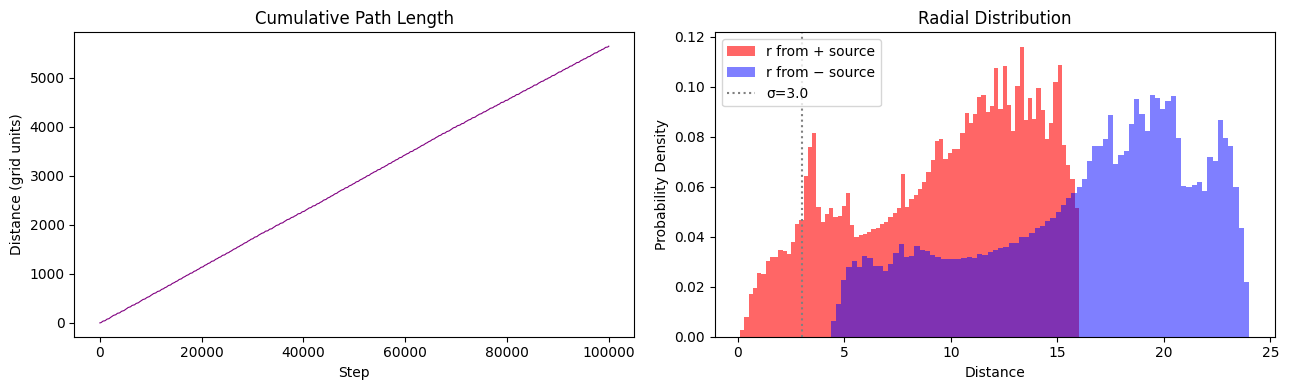

In [ ]:
seg_len  = np.linalg.norm(np.diff(t_arr, axis=0), axis=1)
cum_path = np.concatenate([[0], np.cumsum(seg_len)])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(steps_ax, cum_path, color='purple', lw=0.8)
axes[0].set_title("Cumulative Path Length")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("Distance (grid units)")

axes[1].hist(r_from_pos, bins=80, color='red',  alpha=0.6, label='r from + source', density=True)
axes[1].hist(r_from_neg, bins=80, color='blue', alpha=0.5, label='r from − source', density=True)
axes[1].axvline(sigma, color='gray', ls=':', lw=1.5, label=f'σ={sigma}')
axes[1].set_title("Radial Distribution")
axes[1].set_xlabel("Distance"); axes[1].set_ylabel("Probability Density")
axes[1].legend()

plt.tight_layout(); plt.show()

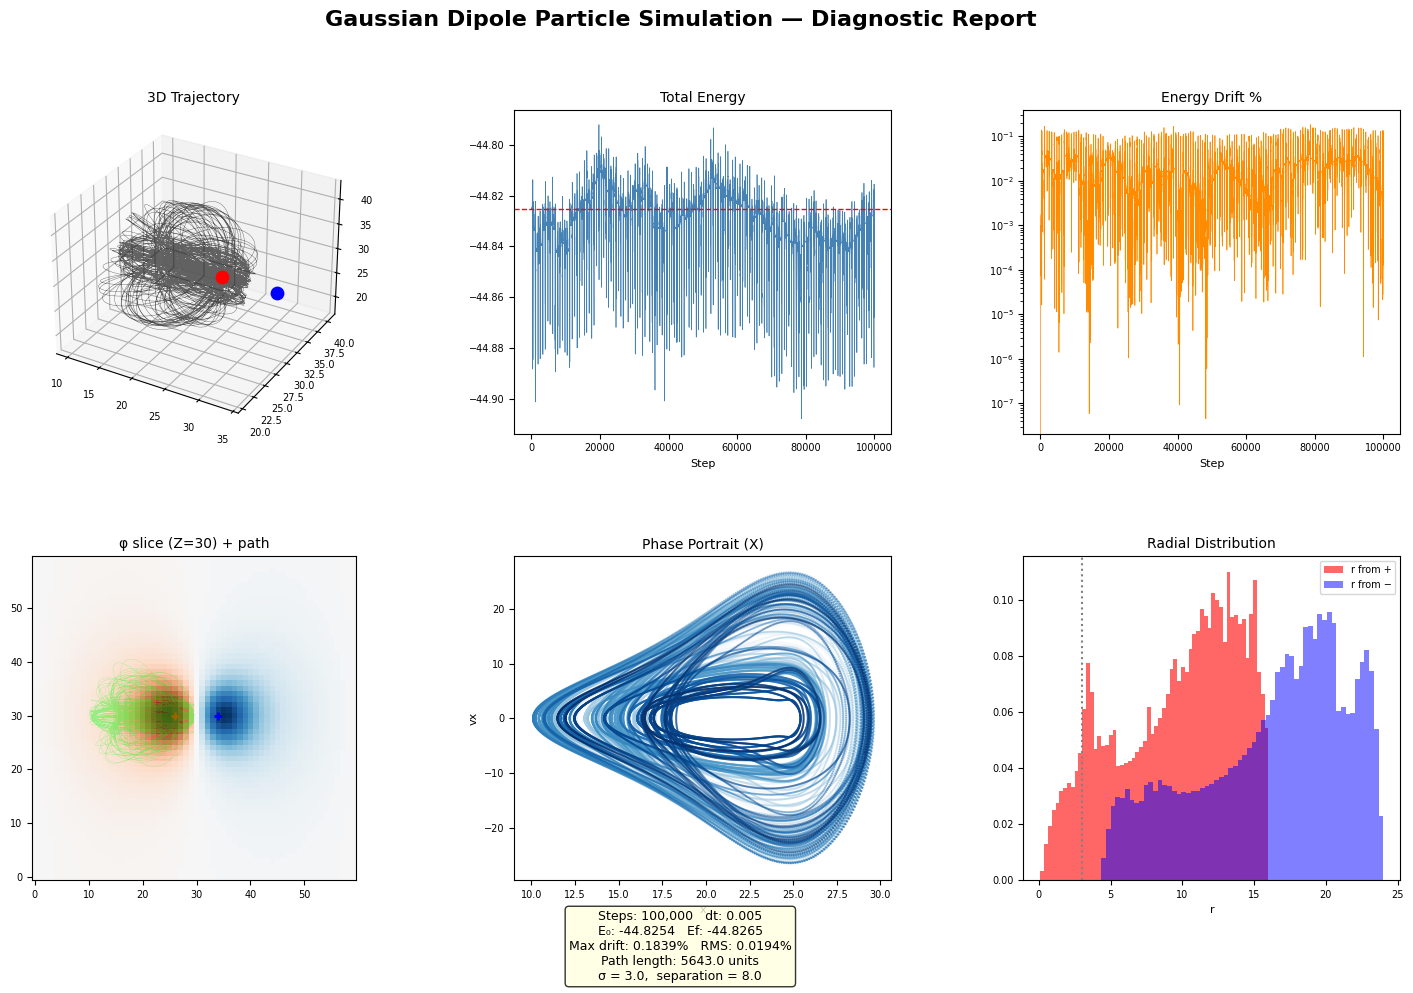

Saved: simulation_report.png


In [ ]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle("Gaussian Dipole Particle Simulation — Diagnostic Report",
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)

# 3D trajectory
ax3d = fig.add_subplot(gs[0, 0], projection='3d')
ax3d.plot(t_arr[:,0], t_arr[:,1], t_arr[:,2],
          color='black', lw=0.3, alpha=0.6)
ax3d.scatter(*[x1,y1,z1], color='red',  s=80)
ax3d.scatter(*[x2,y2,z2], color='blue', s=80)
ax3d.set_title("3D Trajectory", fontsize=10)
ax3d.tick_params(labelsize=7)

# Energy
ax_e = fig.add_subplot(gs[0, 1])
ax_e.plot(steps_ax, e_arr, lw=0.5, color='steelblue')
ax_e.axhline(E0, color='red', ls='--', lw=1)
ax_e.set_title("Total Energy", fontsize=10)
ax_e.set_xlabel("Step", fontsize=8); ax_e.tick_params(labelsize=7)

# Drift %
ax_d = fig.add_subplot(gs[0, 2])
ax_d.plot(steps_ax, drift_pct, lw=0.5, color='darkorange')
ax_d.set_yscale('log')
ax_d.set_title("Energy Drift %", fontsize=10)
ax_d.set_xlabel("Step", fontsize=8); ax_d.tick_params(labelsize=7)

# φ slice + trajectory
ax_phi = fig.add_subplot(gs[1, 0])
ax_phi.imshow(phi[:,:,z_slice].T, origin='lower', cmap='RdBu_r',
              norm=TwoSlopeNorm(vmin=phi_sl.min(), vcenter=0, vmax=phi_sl.max()))
ax_phi.plot(t_arr[:,0], t_arr[:,1], color='lime', lw=0.2, alpha=0.4)
ax_phi.scatter([x1],[y1], color='red', s=40, marker='+', linewidths=2)
ax_phi.scatter([x2],[y2], color='blue',s=40, marker='+', linewidths=2)
ax_phi.set_title(f"φ slice (Z={z_slice}) + path", fontsize=10)
ax_phi.tick_params(labelsize=7)

# Phase portrait x
ax_pp = fig.add_subplot(gs[1, 1])
ax_pp.scatter(t_arr[:,0], v_approx[:,0], c=steps_ax,
              cmap='Blues', s=0.3, alpha=0.5)
ax_pp.set_title("Phase Portrait (X)", fontsize=10)
ax_pp.set_xlabel("x", fontsize=8); ax_pp.set_ylabel("vx", fontsize=8)
ax_pp.tick_params(labelsize=7)

# Radial histogram
ax_rh = fig.add_subplot(gs[1, 2])
ax_rh.hist(r_from_pos, bins=60, color='red',  alpha=0.6, density=True, label='r from +')
ax_rh.hist(r_from_neg, bins=60, color='blue', alpha=0.5, density=True, label='r from −')
ax_rh.axvline(sigma, color='gray', ls=':', lw=1.5)
ax_rh.set_title("Radial Distribution", fontsize=10)
ax_rh.set_xlabel("r", fontsize=8); ax_rh.legend(fontsize=7)
ax_rh.tick_params(labelsize=7)

# Stats text box
stats_text = (
    f"Steps: {steps:,}   dt: {dt}\n"
    f"E₀: {E0:.4f}   Ef: {e_arr[-1]:.4f}\n"
    f"Max drift: {max_drift:.4f}%   RMS: {rms_drift:.4f}%\n"
    f"Path length: {total_dist:.1f} units\n"
    f"σ = {sigma},  separation = {abs(x2-x1):.1f}"
)
fig.text(0.5, 0.01, stats_text, ha='center', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.savefig("simulation_report.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: simulation_report.png")

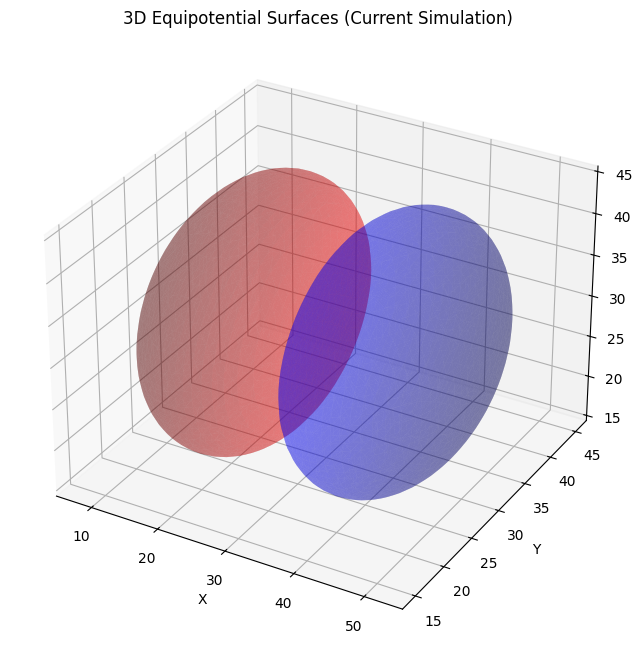

In [ ]:
from skimage import measure

# 1. Visualize Equipotential Surfaces
fig_phi = plt.figure(figsize=(10, 8))
ax_phi = fig_phi.add_subplot(111, projection='3d')

# Use 'phi' from the latest simulation
# Using percentiles to find the 'core' of the dipole influence
v_pos, f_pos, _, _ = measure.marching_cubes(phi, level=np.percentile(phi, 95))
v_neg, f_neg, _, _ = measure.marching_cubes(phi, level=np.percentile(phi, 5))

# Render the surfaces
ax_phi.plot_trisurf(v_pos[:, 0], v_pos[:, 1], f_pos, v_pos[:, 2], color='red', lw=0, alpha=0.3, label='High Potential')
ax_phi.plot_trisurf(v_neg[:, 0], v_neg[:, 1], f_neg, v_neg[:, 2], color='blue', lw=0, alpha=0.3, label='Low Potential')

ax_phi.set_title("3D Equipotential Surfaces (Current Simulation)")
ax_phi.set_xlabel("X"); ax_phi.set_ylabel("Y"); ax_phi.set_zlabel("Z")
plt.show()

Potential Min: -408.2169
Potential Max: 408.2169


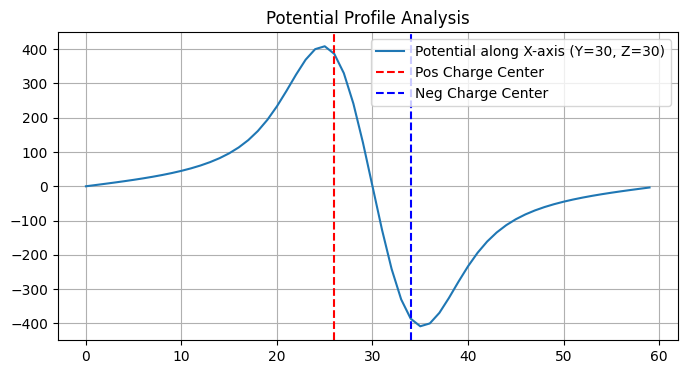

In [ ]:
print(f"Potential Min: {phi.min():.4f}")
print(f"Potential Max: {phi.max():.4f}")

# Check central slice symmetry using the defined NX, NY, NZ
mid_y, mid_z = NY // 2, NZ // 2
phi_slice = phi[:, mid_y, mid_z]

plt.figure(figsize=(8, 4))
plt.plot(phi_slice, label=f'Potential along X-axis (Y={mid_y}, Z={mid_z})')
plt.axvline(x1, color='r', linestyle='--', label='Pos Charge Center')
plt.axvline(x2, color='b', linestyle='--', label='Neg Charge Center')
plt.title("Potential Profile Analysis")
plt.legend()
plt.grid(True)
plt.show()

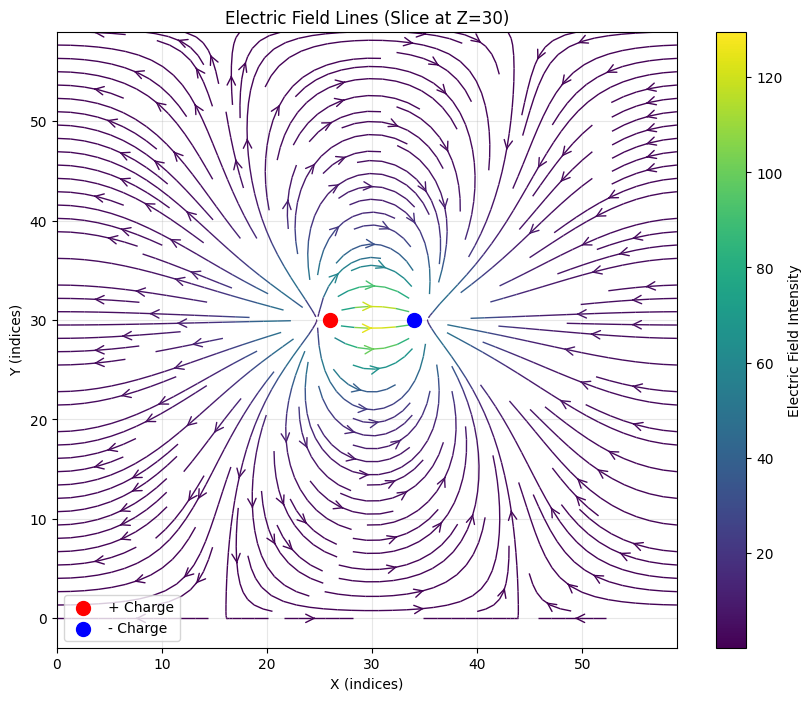

In [ ]:
# 2. Visualize Electric Field Lines (Streamplot Slice)
slice_idx = NZ // 2
x_coord = np.arange(NX)
y_coord = np.arange(NY)

# E-field components in the central plane using latest variables
Ex_s = Ex[:, :, slice_idx]
Ey_s = Ey[:, :, slice_idx]
E_mag = np.sqrt(Ex_s**2 + Ey_s**2)

plt.figure(figsize=(10, 8))

# Aligning correctly for streamplot
strm = plt.streamplot(x_coord, y_coord, Ex_s.T, Ey_s.T, color=E_mag.T, linewidth=1,
                      cmap='viridis', density=1.5, arrowstyle='->', arrowsize=1.5)

plt.colorbar(strm.lines, label='Electric Field Intensity')
plt.scatter([x1], [y1], color='red', s=100, label='+ Charge', zorder=5)
plt.scatter([x2], [y2], color='blue', s=100, label='- Charge', zorder=5)

plt.title(f"Electric Field Lines (Slice at Z={slice_idx})")
plt.xlabel("X (indices)")
plt.ylabel("Y (indices)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
!apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic -y

In [ ]:
!jupyter nbconvert --to pdf nb.ipynb

[NbConvertApp] Converting notebook nb.ipynb to pdf
[NbConvertApp] Support files will be in nb_files/
[NbConvertApp] Making directory ./nb_files
[NbConvertApp] Writing 122908 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 2317494 bytes to nb.pdf
